In [6]:
from datetime import datetime
import logging
import os
import sys
from typing import Any, Optional
from dotenv import find_dotenv, load_dotenv
from pathlib import Path

# Add the parent directory to the Python path to import the sample_helper module
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'python'))
sys.path.insert(0, str(Path().resolve()))
sys.path.insert(0, str(Path("notebooks/02-azure-content-understanding").resolve()))

from dotenv import load_dotenv
load_dotenv() 

from content_understanding_client import AzureContentUnderstandingClient
from sample_helper import save_json_to_file 
from azure.identity import DefaultAzureCredential

load_dotenv(find_dotenv())
logging.basicConfig(level=logging.INFO)

# For authentication, you can use either token-based auth or subscription key; only one is required
AZURE_AI_ENDPOINT = os.getenv("AZURE_AI_ENDPOINT")
# IMPORTANT: Replace with your actual subscription key or set it in your ".env" file if not using token authentication
AZURE_AI_API_KEY = os.getenv("AZURE_AI_API_KEY")
API_VERSION = "2025-11-01"

# Create token provider for Azure AD authentication
def token_provider():
    credential = DefaultAzureCredential()
    token = credential.get_token("https://cognitiveservices.azure.com/.default")
    return token.token

# Create the Content Understanding client
try:
    client = AzureContentUnderstandingClient(
        endpoint=AZURE_AI_ENDPOINT,
        api_version=API_VERSION,
        subscription_key=AZURE_AI_API_KEY,
        token_provider=token_provider if not AZURE_AI_API_KEY else None,
        x_ms_useragent="azure-ai-content-understanding-python-sample-ga"    # The user agent is used for tracking sample usage and does not provide identity information. You can change this if you want to opt out of tracking.
    )
    credential_type = "Subscription Key" if AZURE_AI_API_KEY else "Azure AD Token"
    print(f"✅ Client created successfully")
    print(f"   Endpoint: {AZURE_AI_ENDPOINT}")
    print(f"   Credential: {credential_type}")
    print(f"   API Version: {API_VERSION}")
except Exception as e:
    credential_type = "Subscription Key" if AZURE_AI_API_KEY else "Azure AD Token"
    print(f"❌ Failed to create client")
    print(f"   Endpoint: {AZURE_AI_ENDPOINT}")
    print(f"   Credential: {credential_type}")
    print(f"   Error: {e}")
    raise

✅ Client created successfully
   Endpoint: https://azure-foundry-westus-resource.services.ai.azure.com/
   Credential: Subscription Key
   API Version: 2025-11-01


In [7]:
import time
import json

license_analyzer_id = f"license_agreement_extraction_{int(time.time())}"

license_agreement_analyzer = {
    "baseAnalyzerId": "prebuilt-document",
    "description": (
        "Analyzer for extracting key legal and commercial terms from "
        "License Agreements, including parties, dates, term, renewal, "
        "governing law, license scope, exclusivity, and termination rights."
    ),
    "config": {
        "returnDetails": True,
        "enableOcr": True,
        "enableLayout": True,
        "estimateFieldSourceAndConfidence": True
    },
    "fieldSchema": {
        "name": "LicenseAgreementFields",
        "fields": {

            # 1. Parties
            "Parties": {
                "type": "array",
                "method": "extract",
                "description": (
                    "Entities entering into the agreement, typically identified "
                    "as licensor, licensee, or other parties."
                ),
                "items": {"type": "string"}
            },

            # 2. Agreement Date
            "AgreementDate": {
                "type": "string",
                "method": "extract",
                "description": "The date on which the agreement was executed or signed."
            },

            # 3. Effective Date
            "EffectiveDate": {
                "type": "string",
                "method": "extract",
                "description": (
                    "The date on which the agreement becomes effective, which "
                    "may be explicit or defined relative to execution."
                )
            },

            # 4. Term (duration or end)
            "Term": {
                "type": "object",
                "method": "generate",
                "description": (
                    "The duration of the agreement, including whether it is "
                    "fixed-term, perpetual, or tied to termination conditions."
                ),
                "properties": {
                    "EndDate": {
                        "type": "string",
                        "description": "The date on which the agreement term expires, if any."
                    },
                    "Duration": {
                        "type": "string",
                        "description": "Textual description of the agreement duration."
                    }
                }
            },

            # 5. Renewal Term
            "RenewalTerm": {
                "type": "string",
                "method": "extract",
                "description": (
                    "Description of any automatic or optional renewal term "
                    "following the initial term."
                )
            },

            # 6. Notice to Terminate Renewal
            "NoticeToTerminateRenewal": {
                "type": "string",
                "method": "extract",
                "description": (
                    "Required notice period or conditions to prevent renewal "
                    "of the agreement."
                )
            },

            # 7. Governing Law
            "GoverningLaw": {
                "type": "string",
                "method": "extract",
                "description": (
                    "State, province, or country whose laws govern interpretation "
                    "of the agreement."
                )
            },

            # 8. License Grant (scope)
            "LicenseGrant": {
                "type": "string",
                "method": "generate",
                "description": (
                    "Summary of the rights granted under the license, including "
                    "scope of use, field of use, and any territorial limitations."
                )
            },

            # 9. Exclusivity
            "Exclusivity": {
                "type": "boolean",
                "method": "extract",
                "description": (
                    "Indicates whether the license is exclusive or non-exclusive."
                )
            },

            # 10. Termination for Convenience
            "TerminationForConvenience": {
                "type": "boolean",
                "method": "extract",
                "description": (
                    "Whether either party may terminate the agreement without cause, "
                    "typically upon advance notice."
                )
            }
        }
    },
    "models": {
        "completion": "gpt-4.1-mini"
    }
}

print(json.dumps(license_agreement_analyzer, indent=2))

# Create the analyzer
response = client.begin_create_analyzer(
    analyzer_id=license_analyzer_id,
    analyzer_template=license_agreement_analyzer,
)

print("⏳ Waiting for analyzer creation to complete...")
client.poll_result(response)
print(f"✅ Analyzer '{license_analyzer_id}' created successfully!")


{
  "baseAnalyzerId": "prebuilt-document",
  "description": "Analyzer for extracting key legal and commercial terms from License Agreements, including parties, dates, term, renewal, governing law, license scope, exclusivity, and termination rights.",
  "config": {
    "returnDetails": true,
    "enableOcr": true,
    "enableLayout": true,
    "estimateFieldSourceAndConfidence": true
  },
  "fieldSchema": {
    "name": "LicenseAgreementFields",
    "fields": {
      "Parties": {
        "type": "array",
        "method": "extract",
        "description": "Entities entering into the agreement, typically identified as licensor, licensee, or other parties.",
        "items": {
          "type": "string"
        }
      },
      "AgreementDate": {
        "type": "string",
        "method": "extract",
        "description": "The date on which the agreement was executed or signed."
      },
      "EffectiveDate": {
        "type": "string",
        "method": "extract",
        "description":

INFO:content_understanding_client:Analyzer license_agreement_extraction_1770709412 create request accepted.


⏳ Waiting for analyzer creation to complete...


INFO:content_understanding_client:Request 00bb0a07-f0be-439f-9fa3-e65fb2efed8e in progress ...
INFO:content_understanding_client:Request result is ready after 3.33 seconds.


✅ Analyzer 'license_agreement_extraction_1770709412' created successfully!


In [8]:
sample_file_path = 'data/AlliedEsportsEntertainmentInc_20190815_8-K_EX-10.19_11788293_EX-10.19_Content License Agreement.pdf'

# Begin document analysis operation
print(f"🔍 Starting document analysis with analyzer '{license_analyzer_id}'...")
analysis_response = client.begin_analyze_binary(
    analyzer_id=license_analyzer_id,
    file_location=sample_file_path,
)

# Wait for analysis completion
print(f"⏳ Waiting for document analysis to complete...")
analysis_result = client.poll_result(analysis_response)
print(f"✅ Document analysis completed successfully!")

🔍 Starting document analysis with analyzer 'license_agreement_extraction_1770709412'...


INFO:content_understanding_client:Analyzing binary file data/AlliedEsportsEntertainmentInc_20190815_8-K_EX-10.19_11788293_EX-10.19_Content License Agreement.pdf with analyzer: license_agreement_extraction_1770709412


⏳ Waiting for document analysis to complete...


INFO:content_understanding_client:Request d8ea3ae0-284f-4907-8ab7-6506359e4f1c in progress ...
INFO:content_understanding_client:Request d8ea3ae0-284f-4907-8ab7-6506359e4f1c in progress ...
INFO:content_understanding_client:Request d8ea3ae0-284f-4907-8ab7-6506359e4f1c in progress ...
INFO:content_understanding_client:Request d8ea3ae0-284f-4907-8ab7-6506359e4f1c in progress ...
INFO:content_understanding_client:Request d8ea3ae0-284f-4907-8ab7-6506359e4f1c in progress ...
INFO:content_understanding_client:Request d8ea3ae0-284f-4907-8ab7-6506359e4f1c in progress ...
INFO:content_understanding_client:Request result is ready after 18.88 seconds.


✅ Document analysis completed successfully!


In [9]:
# 10 pages document took 23 seconds

In [11]:
if analysis_result and "result" in analysis_result:
    result = analysis_result["result"]
    contents = result.get("contents", [])
    
    if contents:
        first_content = contents[0]
        
        # Display extracted fields
        fields = first_content.get("fields", {})
        print("📊 Extracted Fields:")
        print("-" * 80)
        if fields:
            for field_name, field_value in fields.items():
                field_type = field_value.get("type")
                if field_type == "string":
                    print(f"{field_name}: {field_value.get('valueString')}")
                elif field_type == "number":
                    print(f"{field_name}: {field_value.get('valueNumber')}")
                elif field_type == "array":
                    print(f"{field_name} (array with {len(field_value.get('valueArray', []))} items):")
                    for idx, item in enumerate(field_value.get('valueArray', []), 1):
                        if item.get('type') == 'object':
                            print(f"  Item {idx}:")
                            for key, val in item.get('valueObject', {}).items():
                                if val.get('type') == 'string':
                                    print(f"    {key}: {val.get('valueString')}")
                                elif val.get('type') == 'number':
                                    print(f"    {key}: {val.get('valueNumber')}")
                elif field_type == "object":
                    print(f"{field_name}: {field_value.get('valueObject')}")
                print()
        else:
            print("No fields extracted")
        print()
        
        # Display content metadata
        print("📋 Content Metadata:")
        print("-" * 80)
        print(f"Kind: {first_content.get('kind')}")
        print(f"Pages: {first_content.get('startPageNumber')} - {first_content.get('endPageNumber')}")
        print(f"Unit: {first_content.get('unit')}")
        print()
        
    
    # Save full result to file
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_file = f"test_output/license_analysis_result_{timestamp}.json"
    os.makedirs("test_output", exist_ok=True)
    
    with open(output_file, 'w') as f:
        json.dump(analysis_result, f, indent=2)
    
    print(f"💾 Full analysis result saved to: {output_file}")
else:
    print("No analysis result available")

📊 Extracted Fields:
--------------------------------------------------------------------------------
Parties (array with 3 items):

AgreementDate: None

EffectiveDate: February 1, 2018

Term: {'EndDate': {'type': 'string', 'confidence': 0.368}, 'Duration': {'type': 'string', 'valueString': 'This Agreement will be in effect for three (3) years from the Effective Date ("Initial Term") unless terminated earlier in accordance with this Agreement. This Agreement shall automatically extend for an additional two (2) years on the same terms herein ("Renewal Term") provided WPT receives payments greater than twelve million U.S. dollars ($12,000,000) within the Initial Term. The Initial Term and any such Renewal Term are collectively referred to as the "Term."', 'spans': [{'offset': 3200, 'length': 133}, {'offset': 3334, 'length': 129}, {'offset': 3464, 'length': 138}, {'offset': 3603, 'length': 65}], 'confidence': 0.66, 'source': 'D(2,1.4172,0.6257,7.4609,0.6271,7.4609,0.7652,1.4172,0.7638);D(2

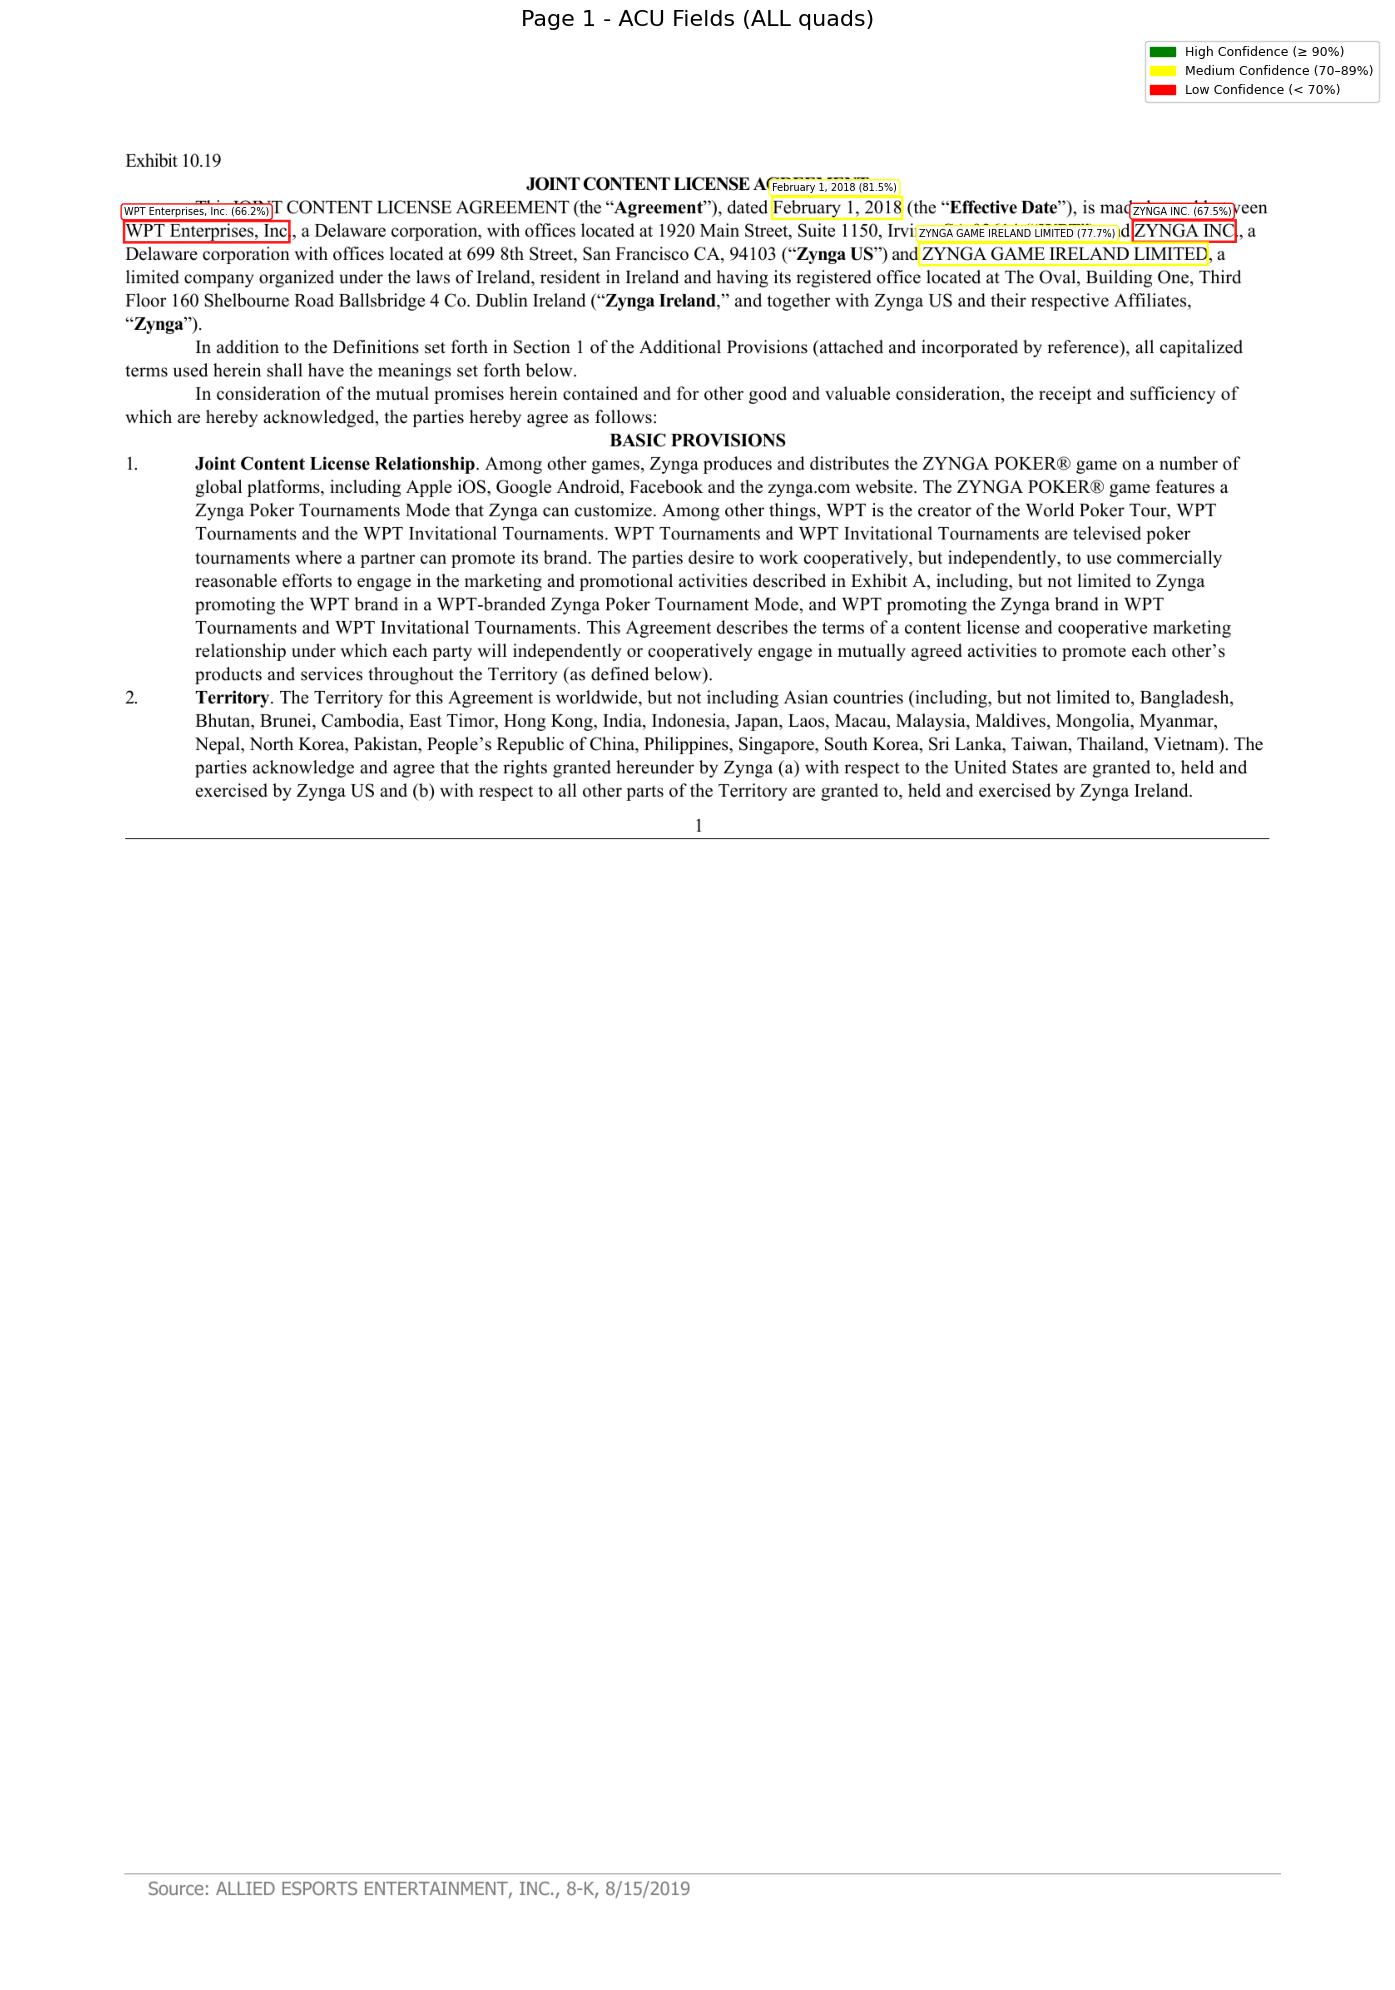

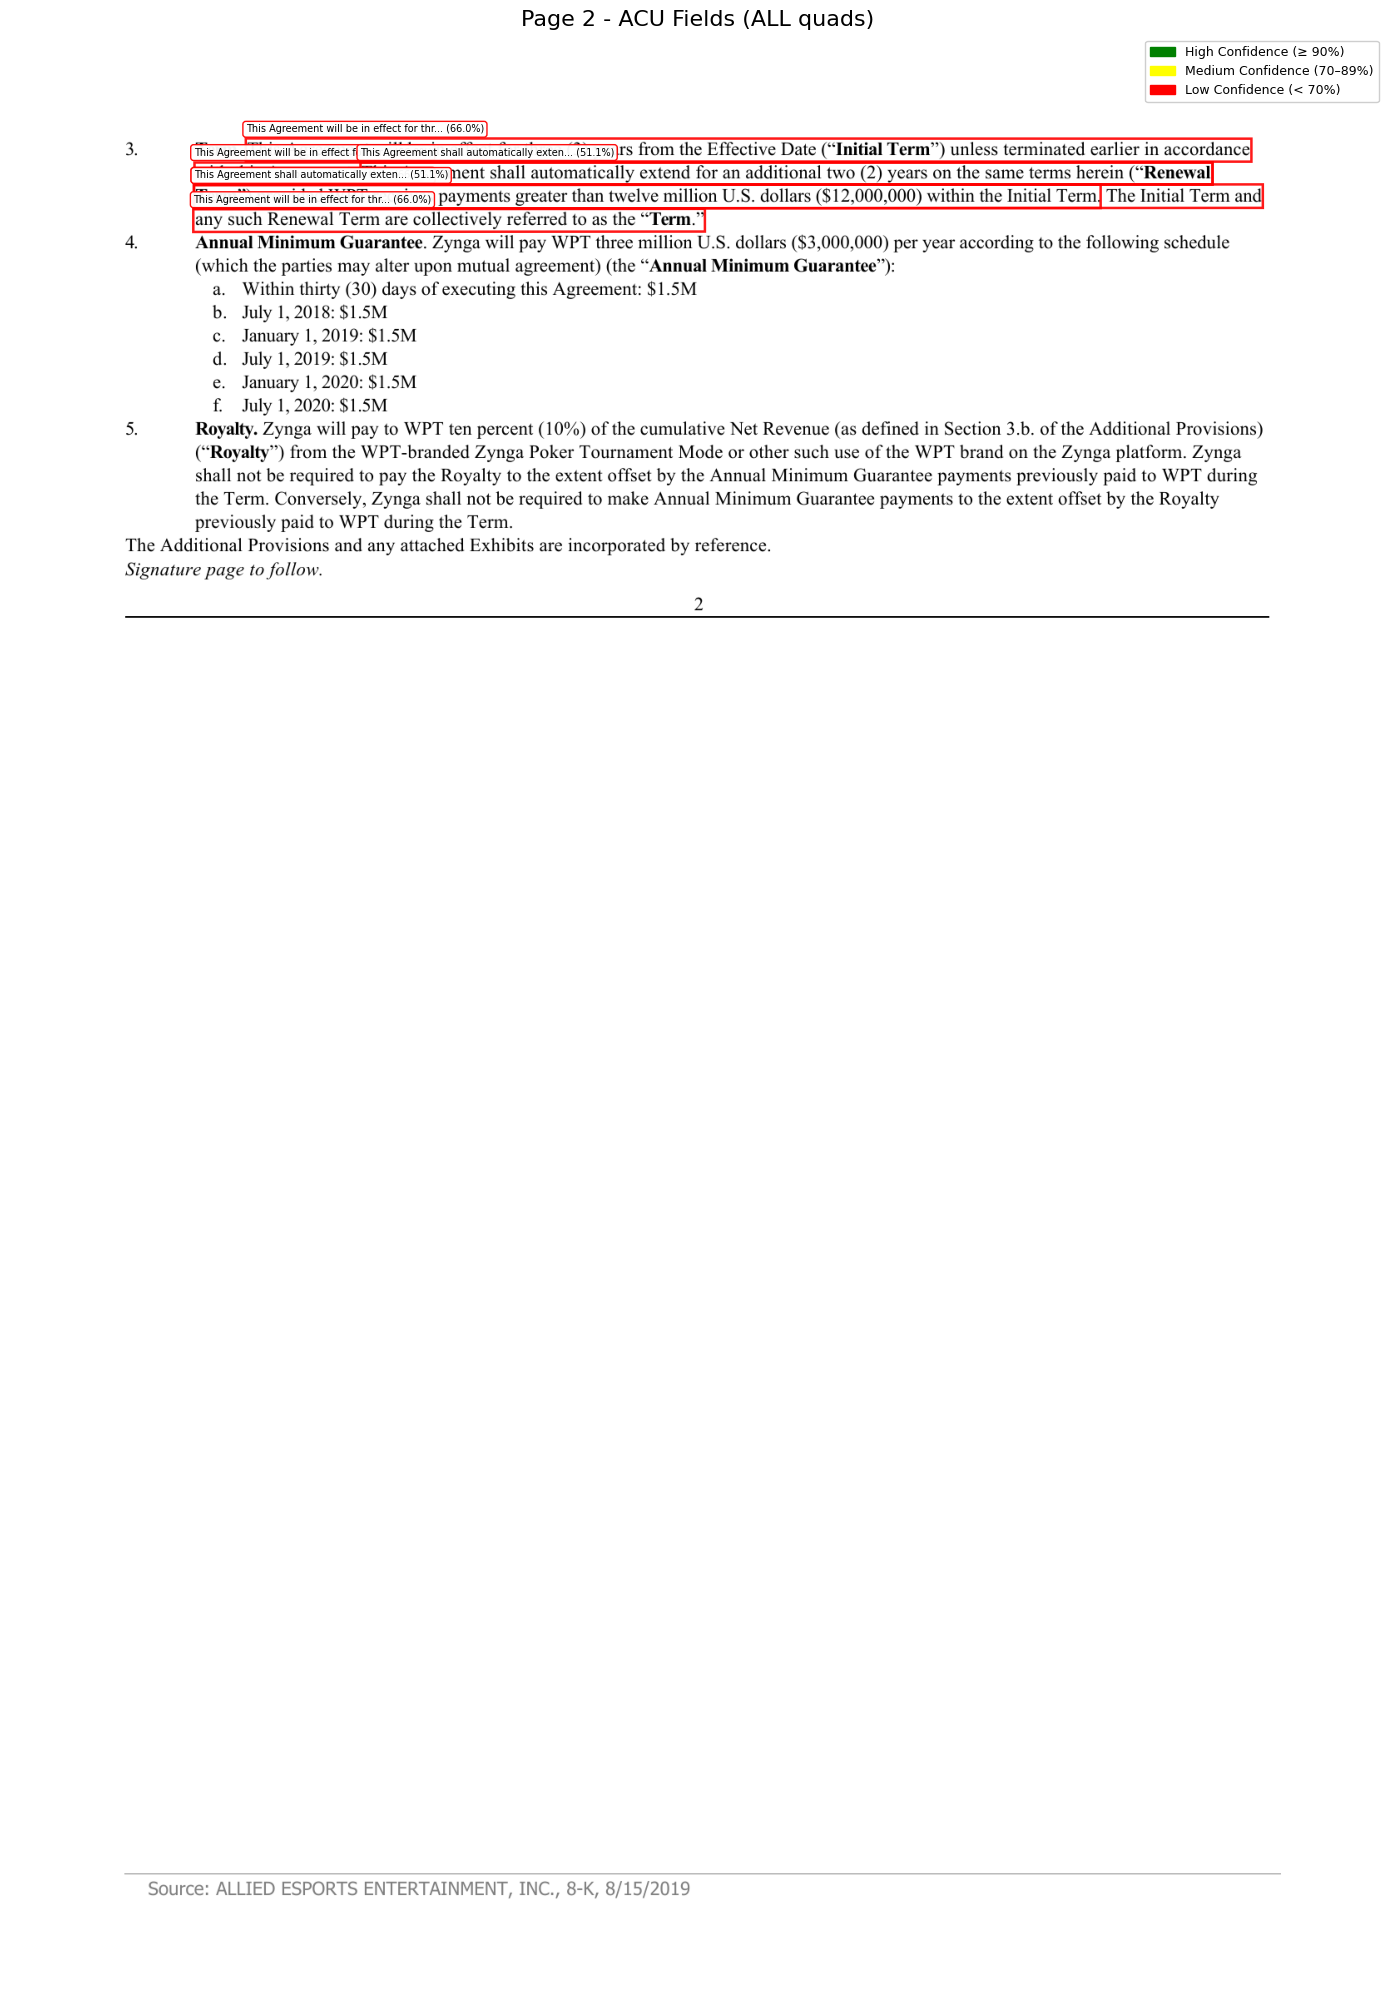

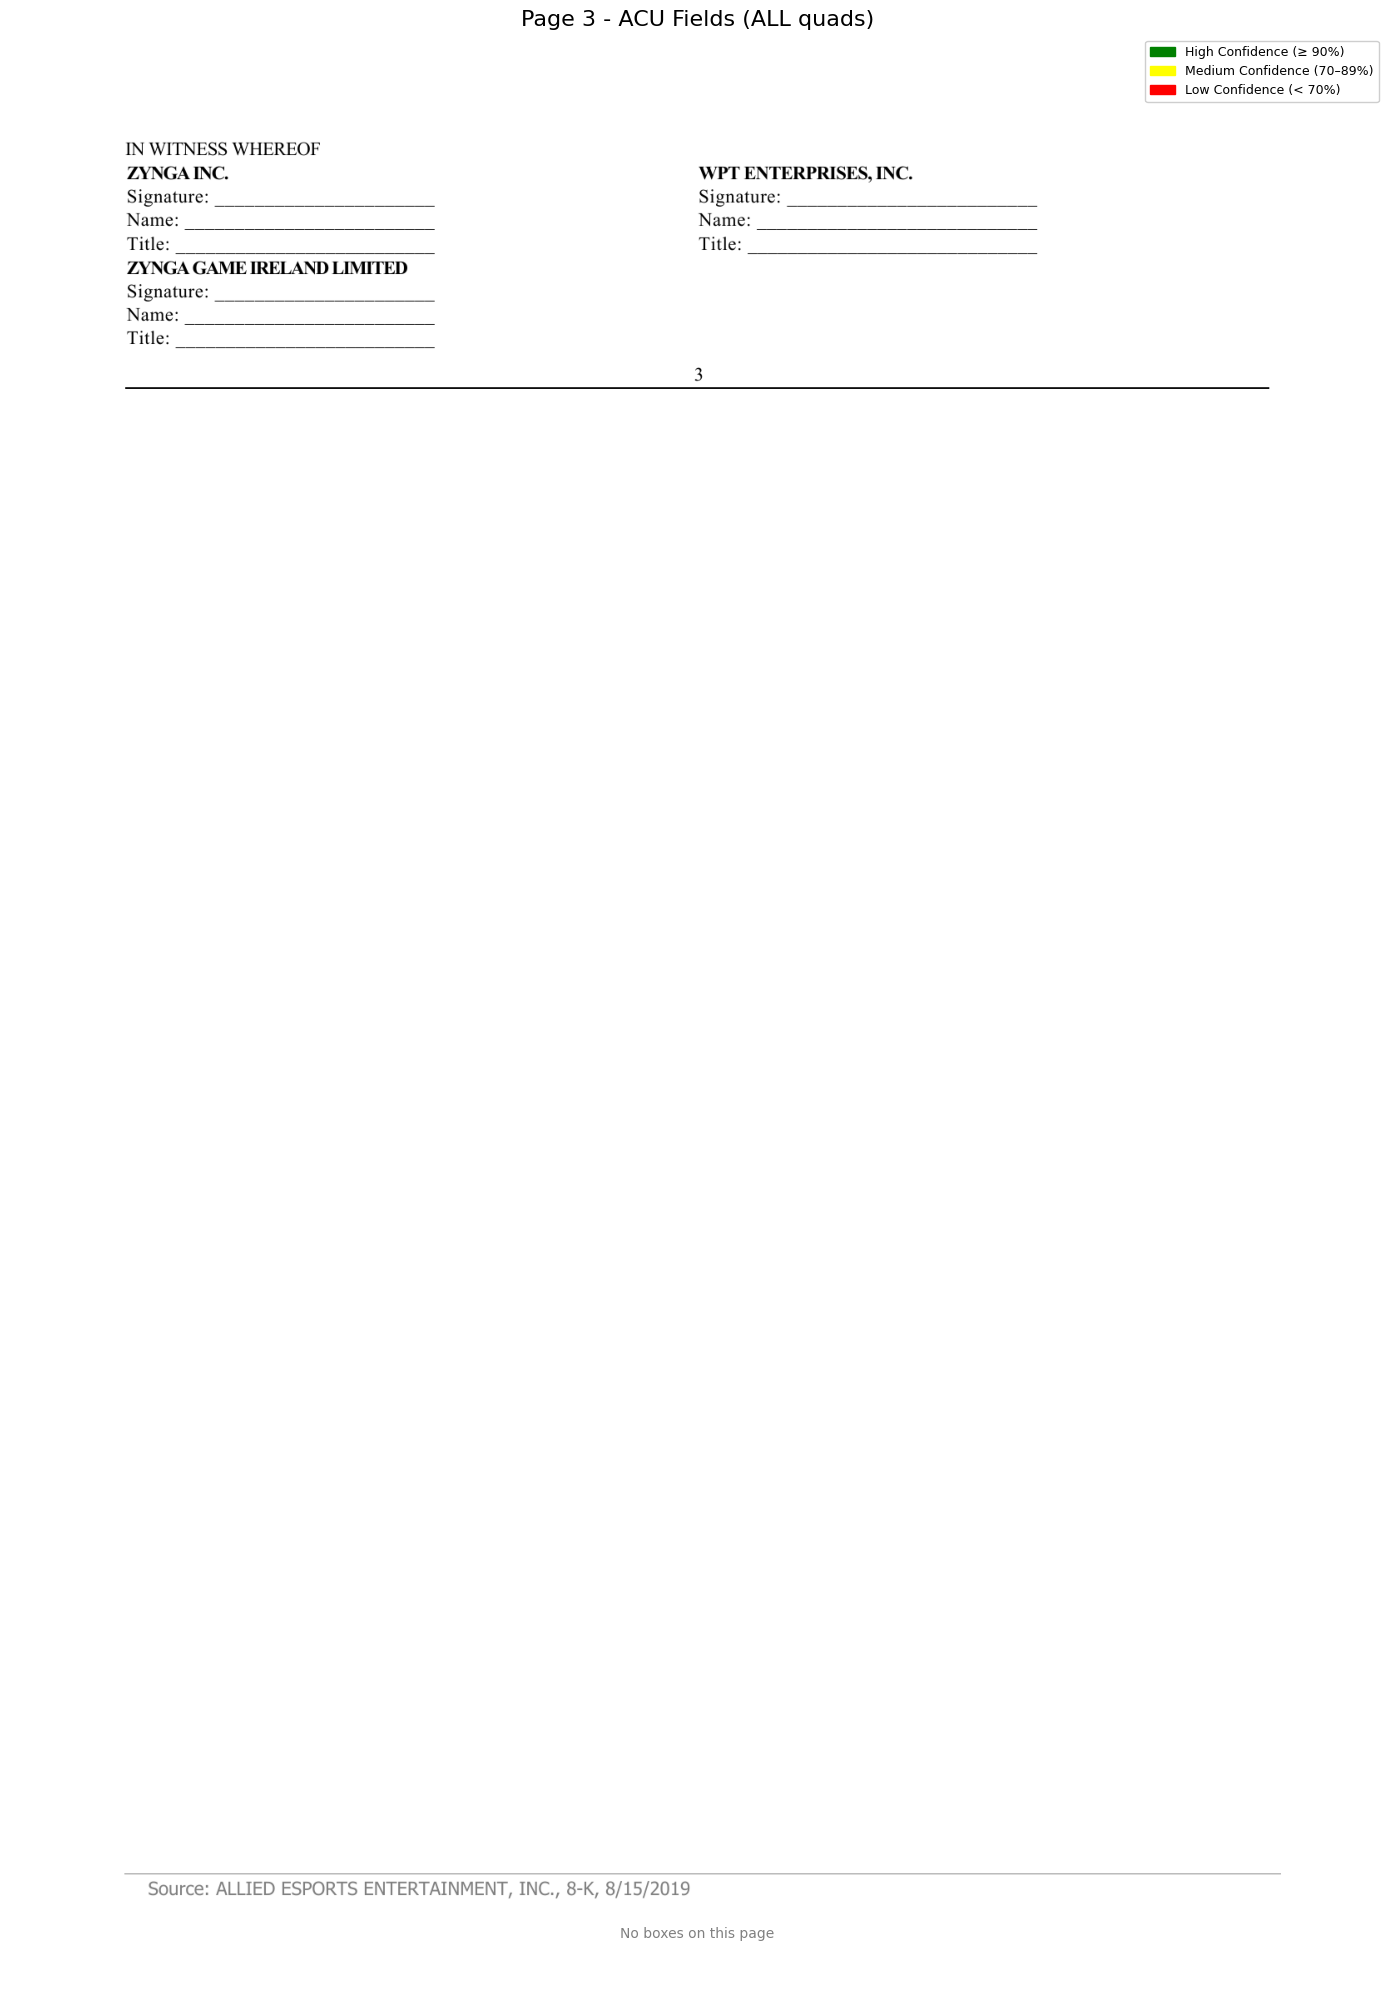

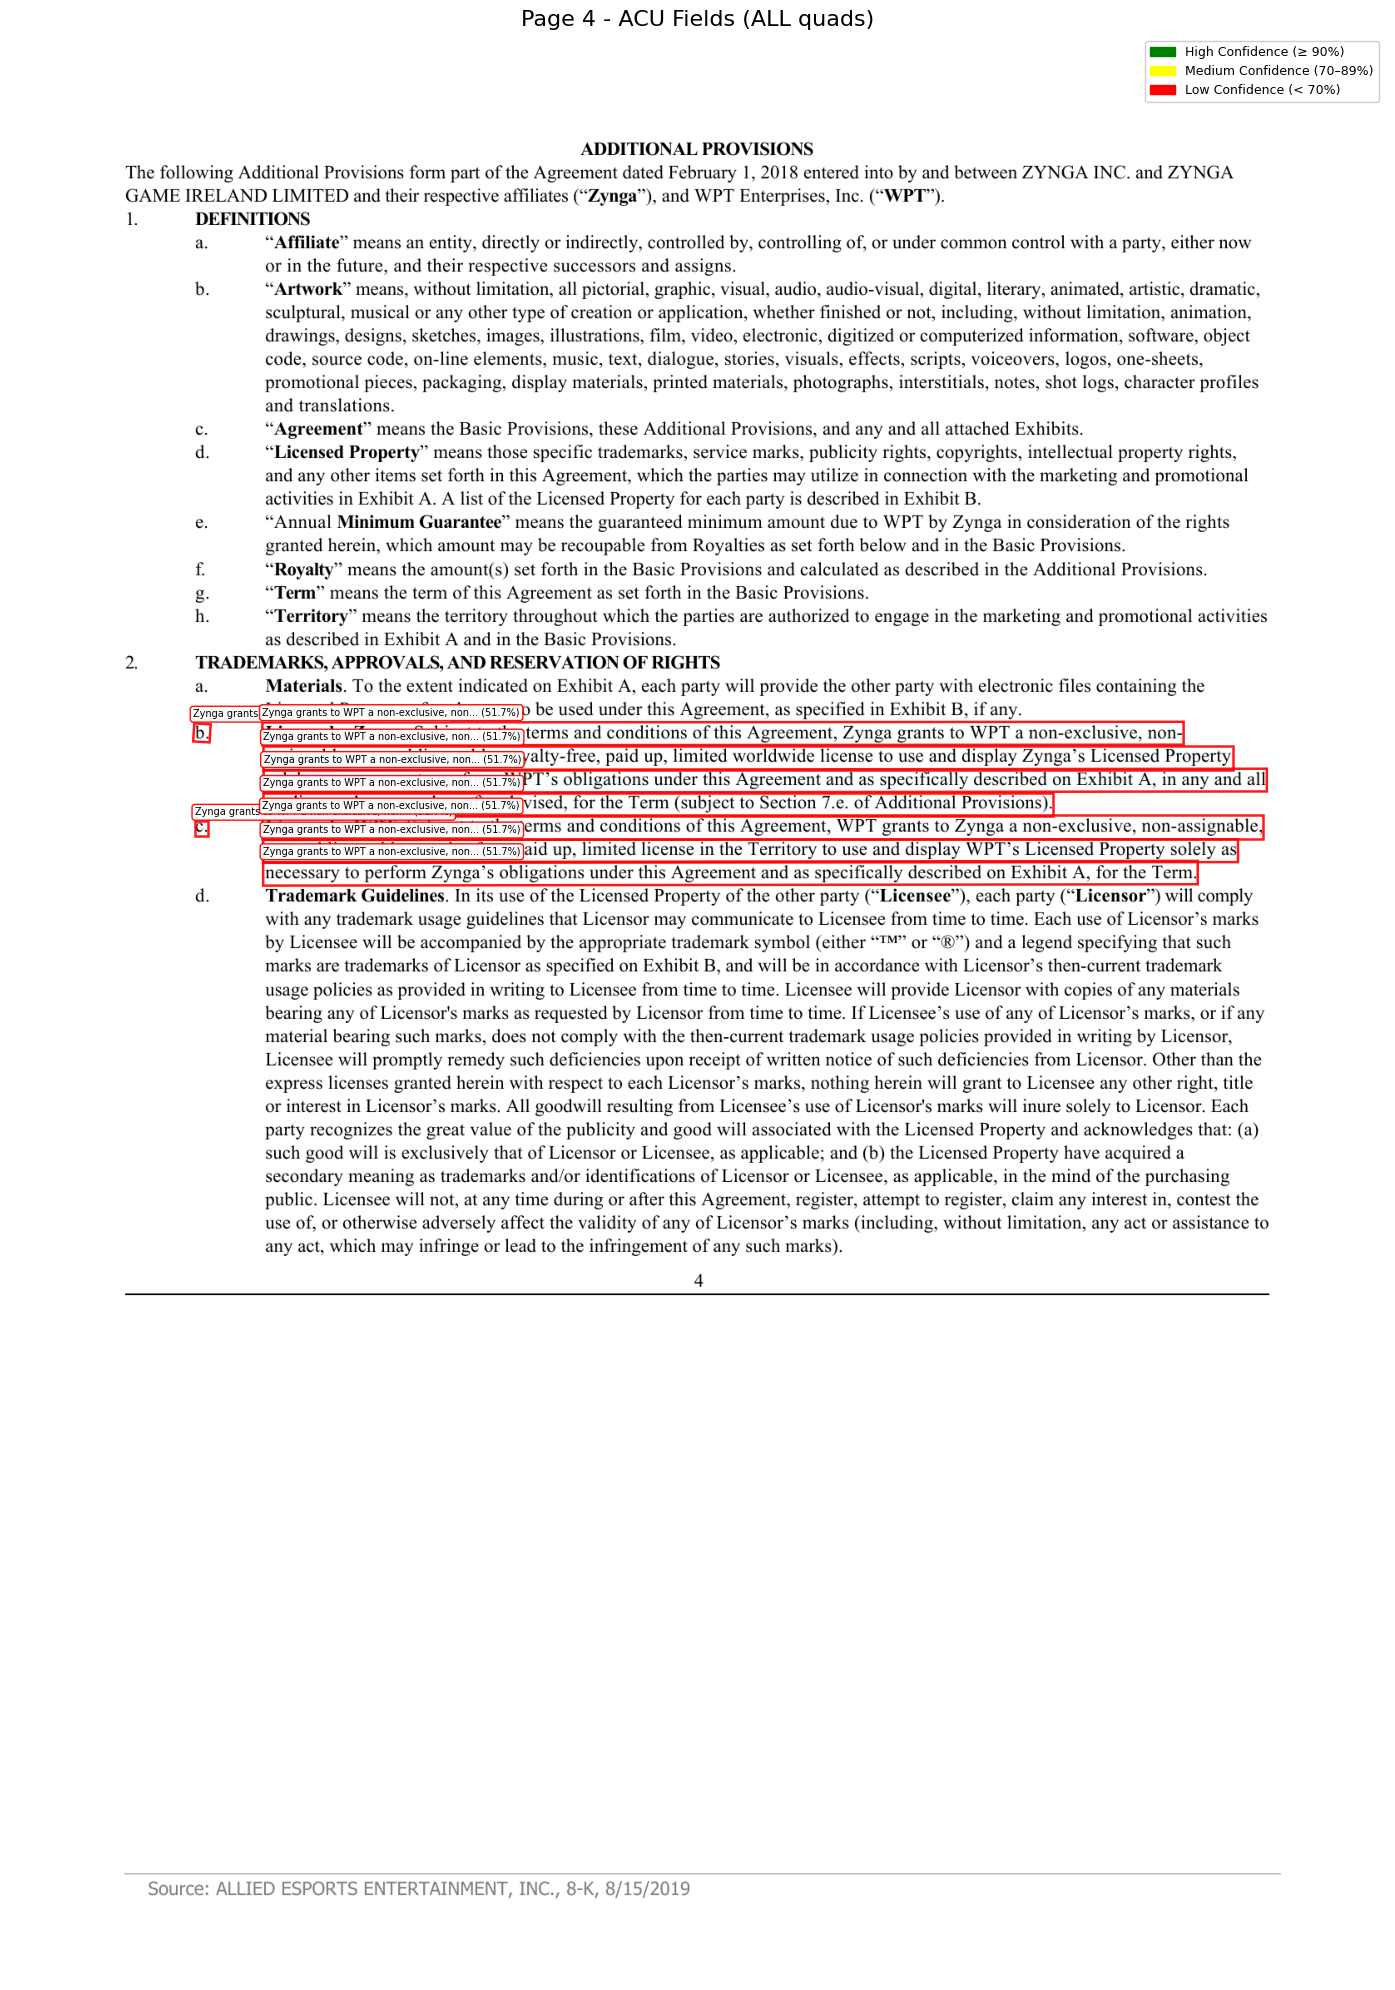

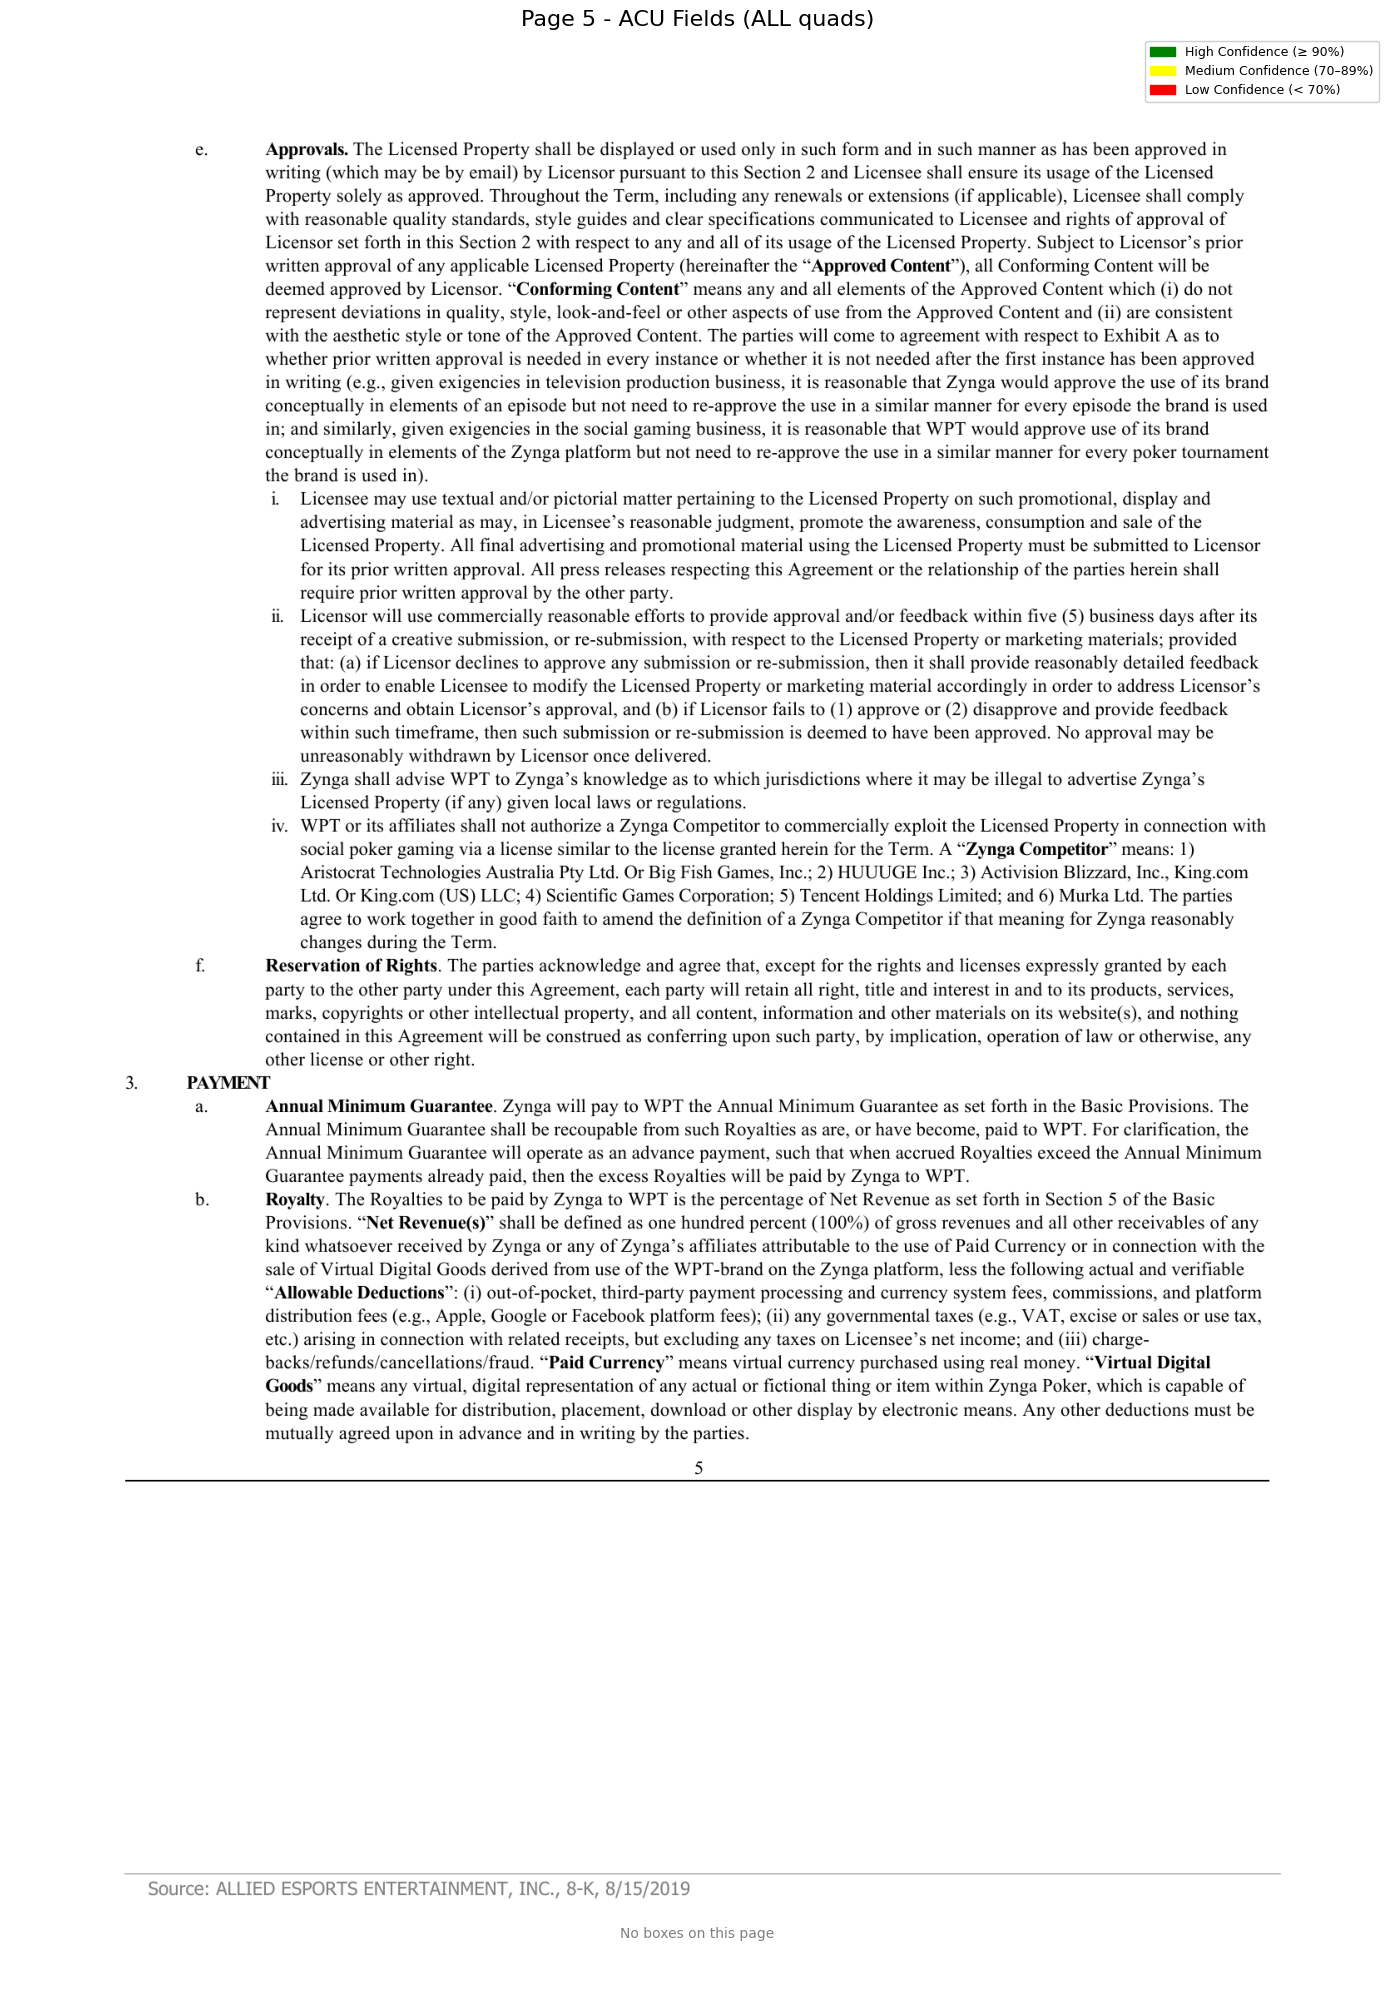

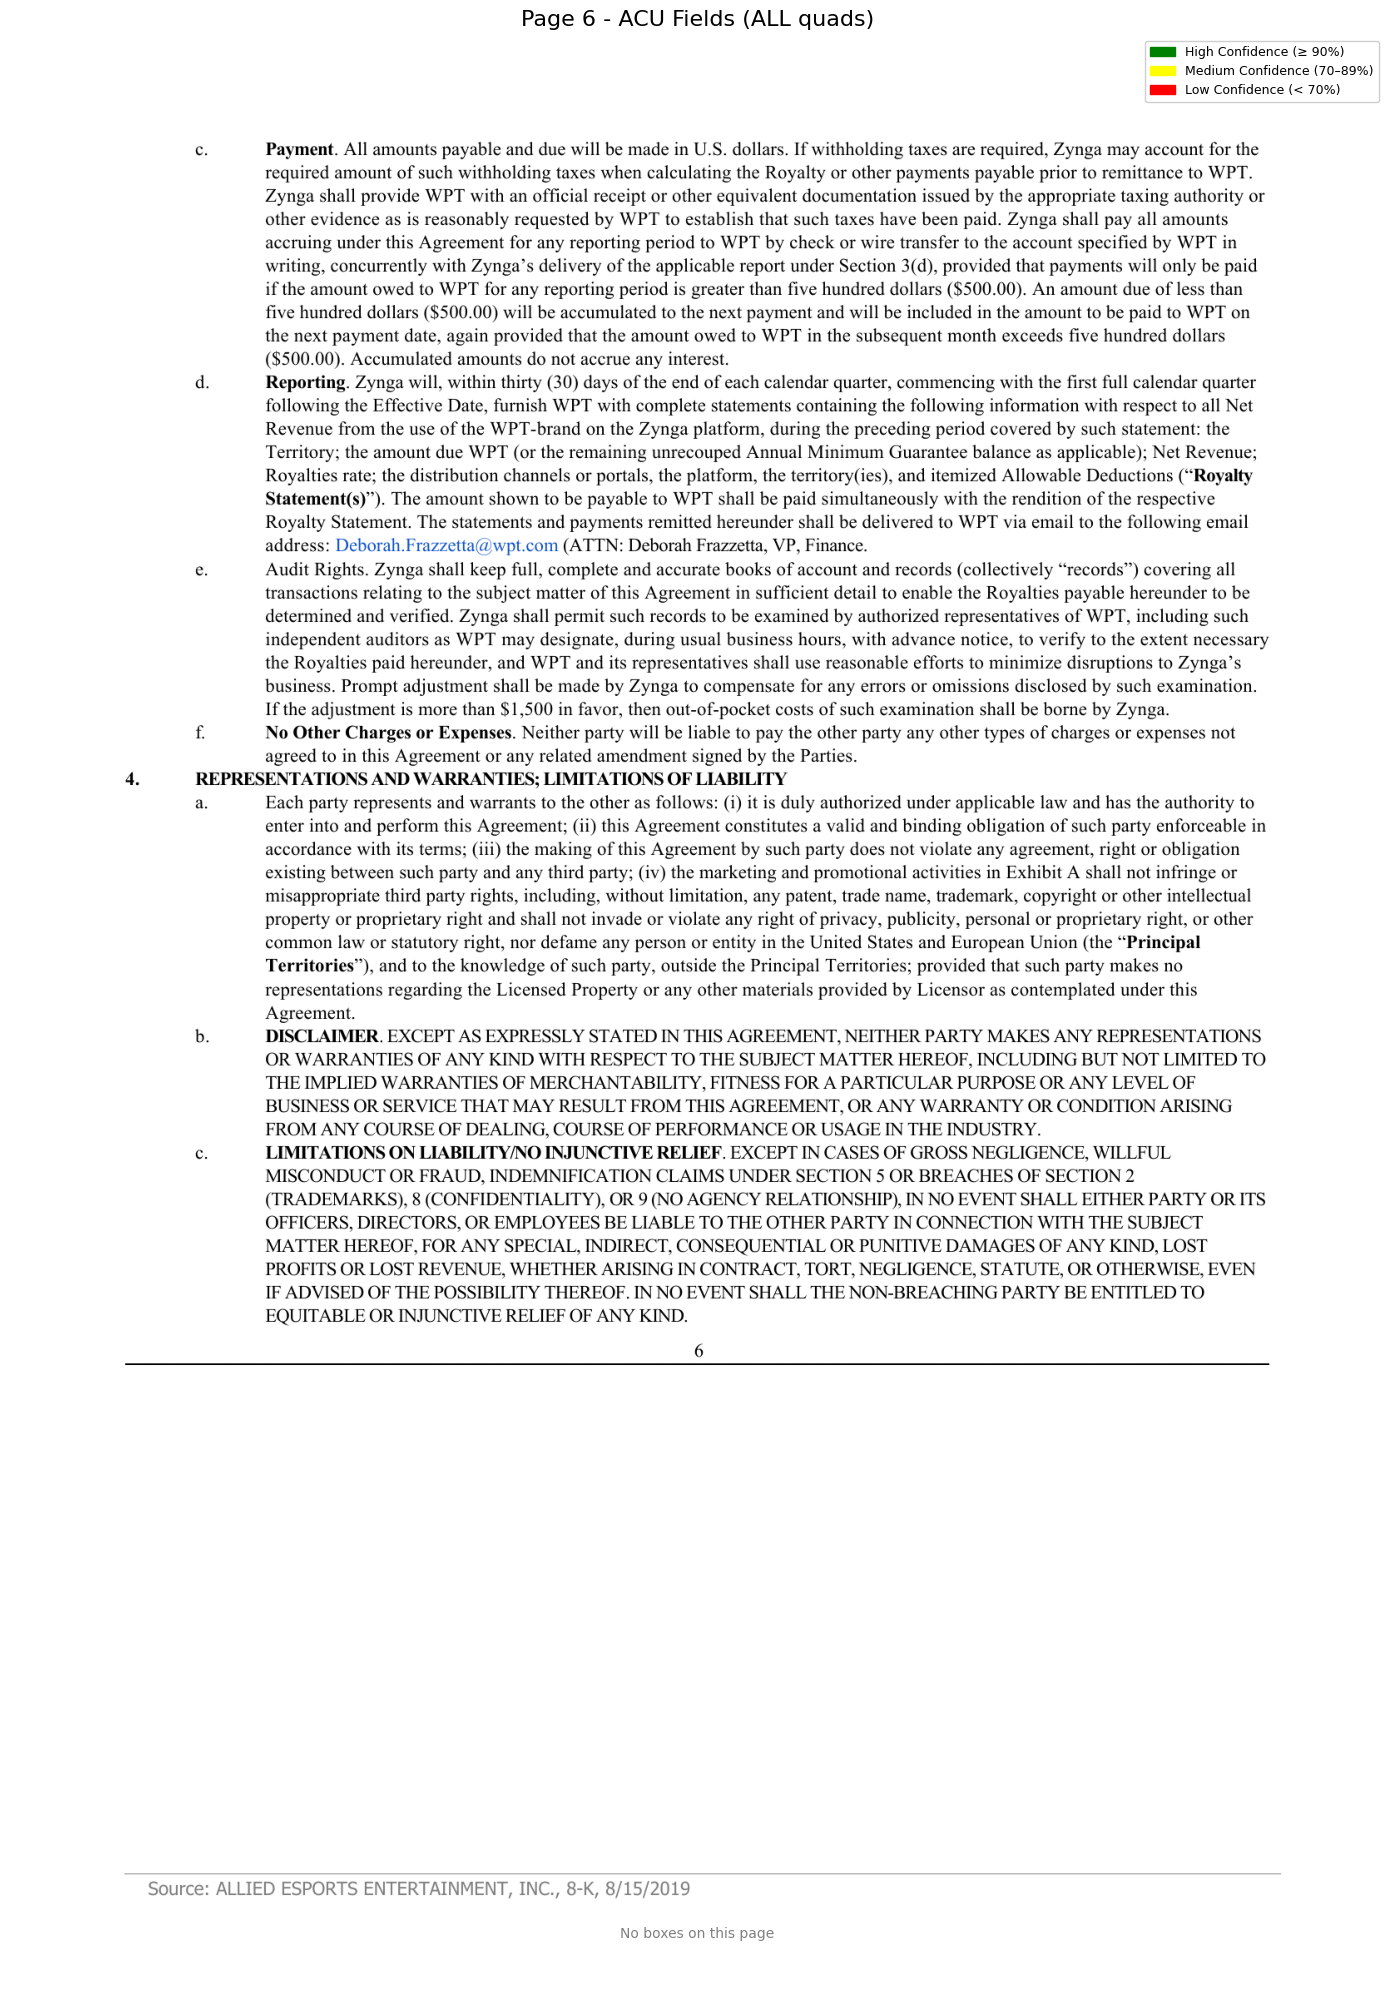

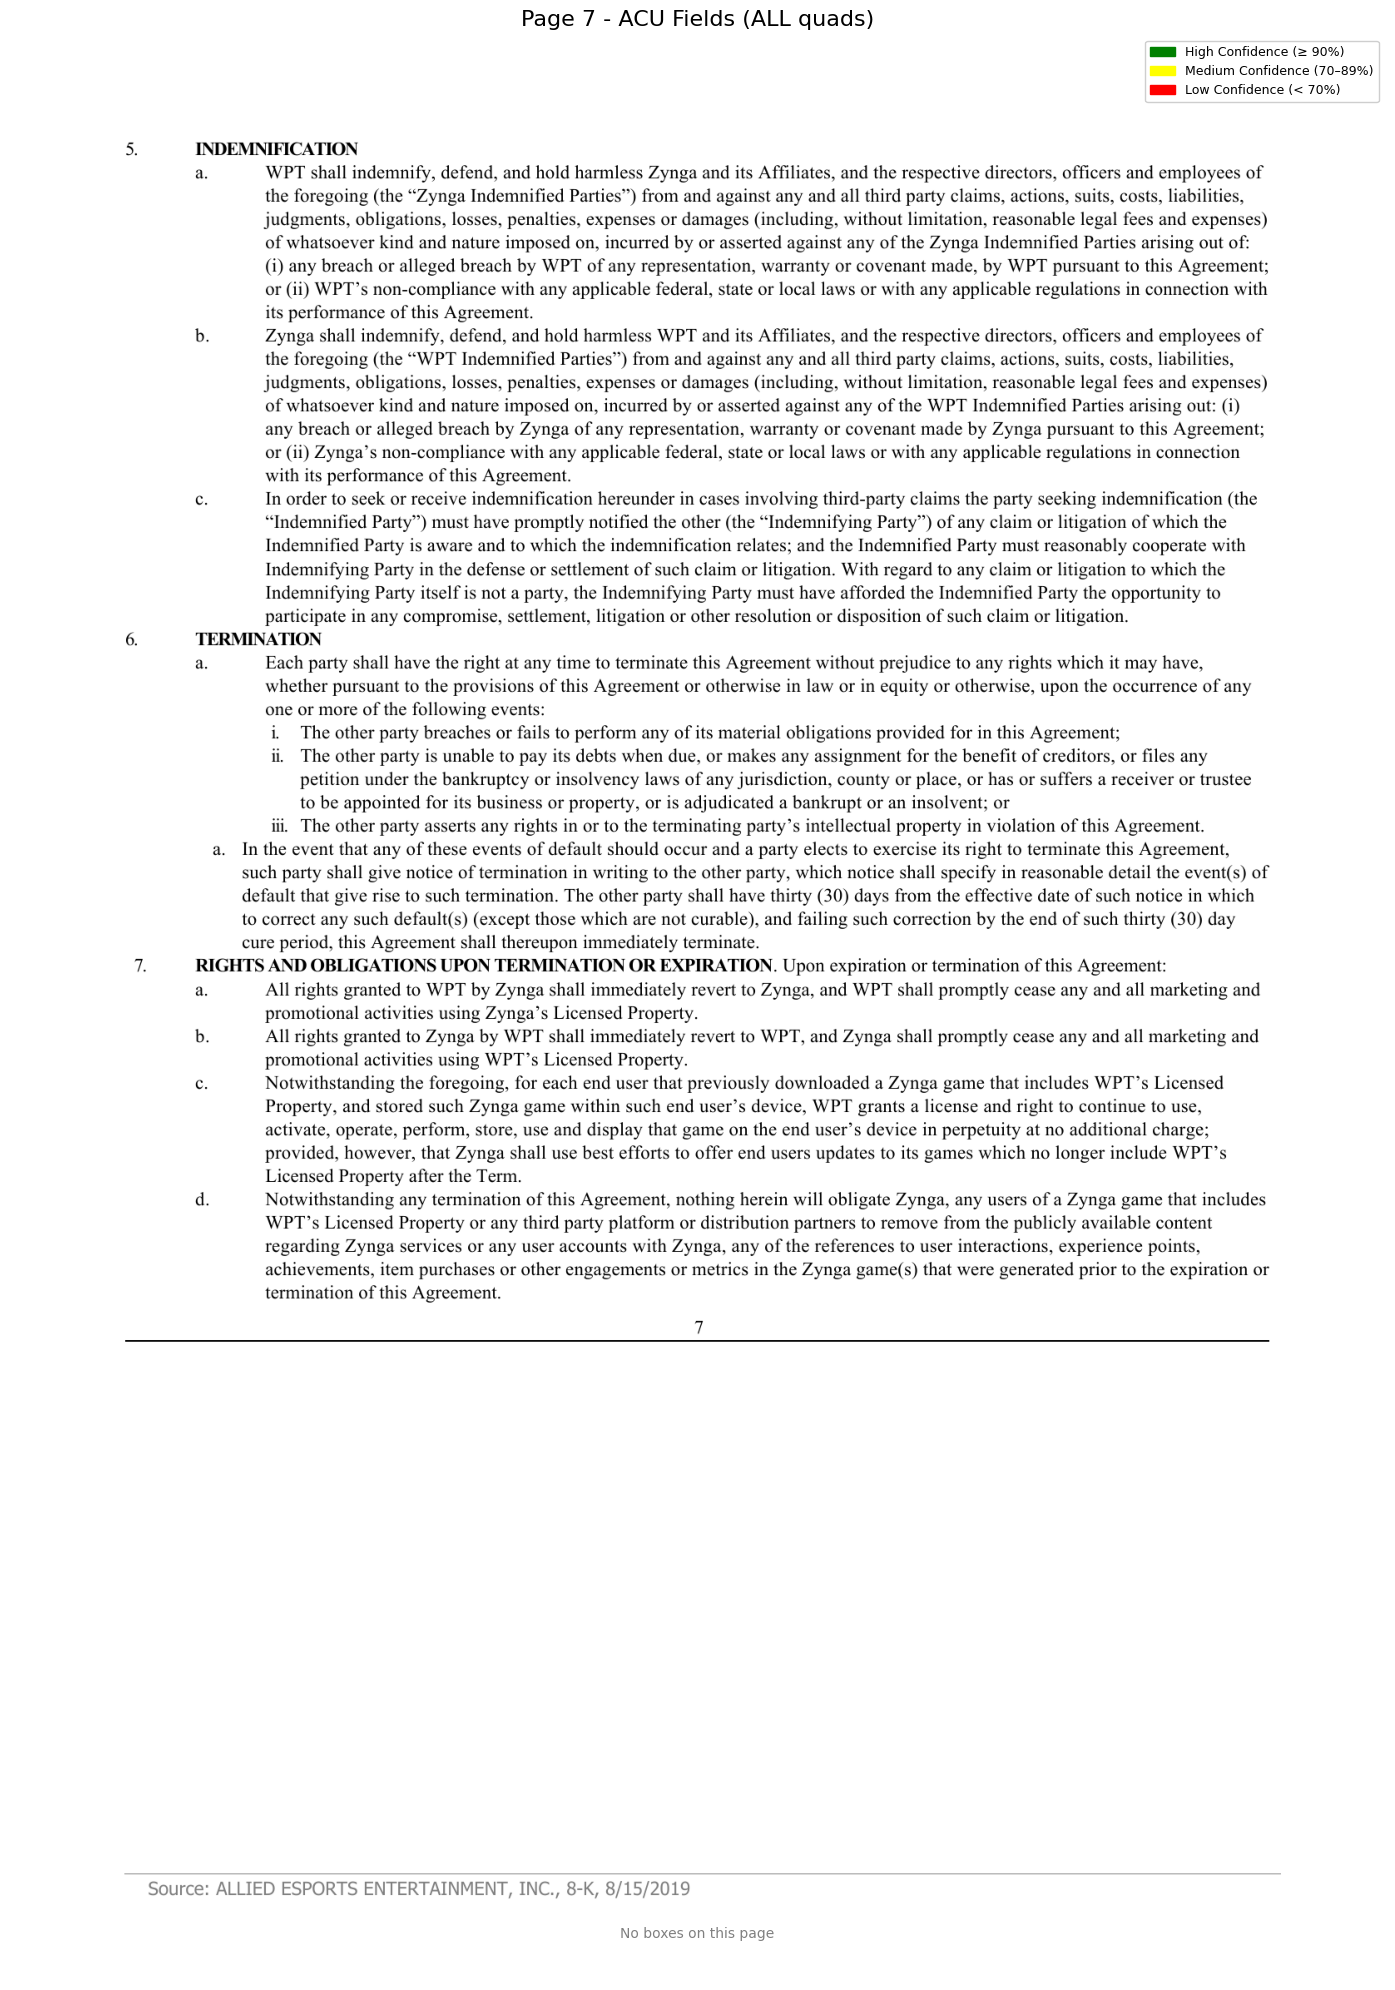

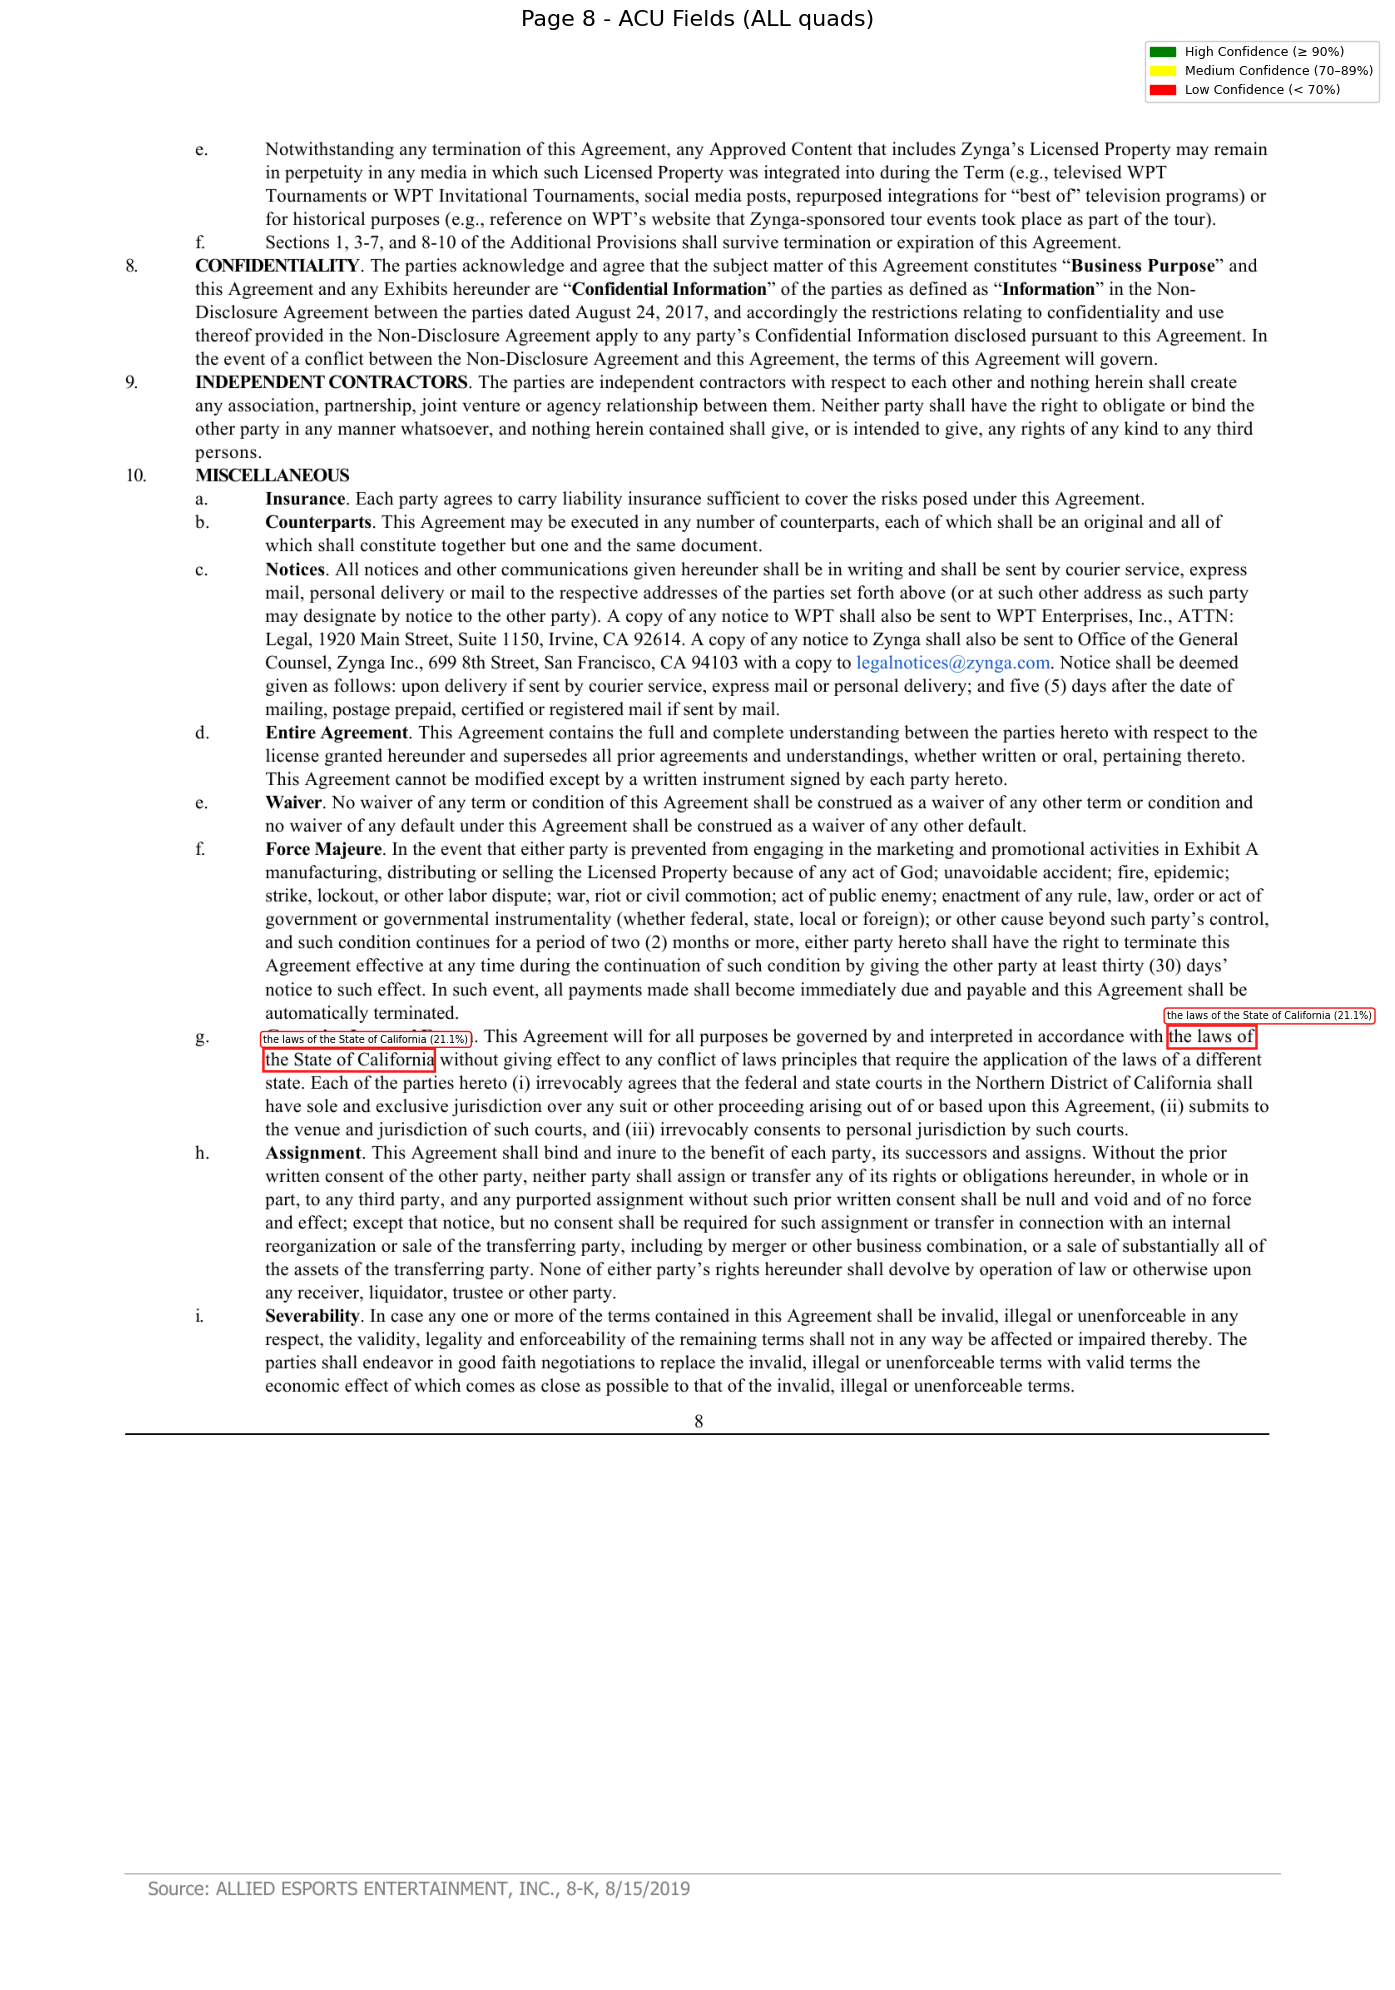

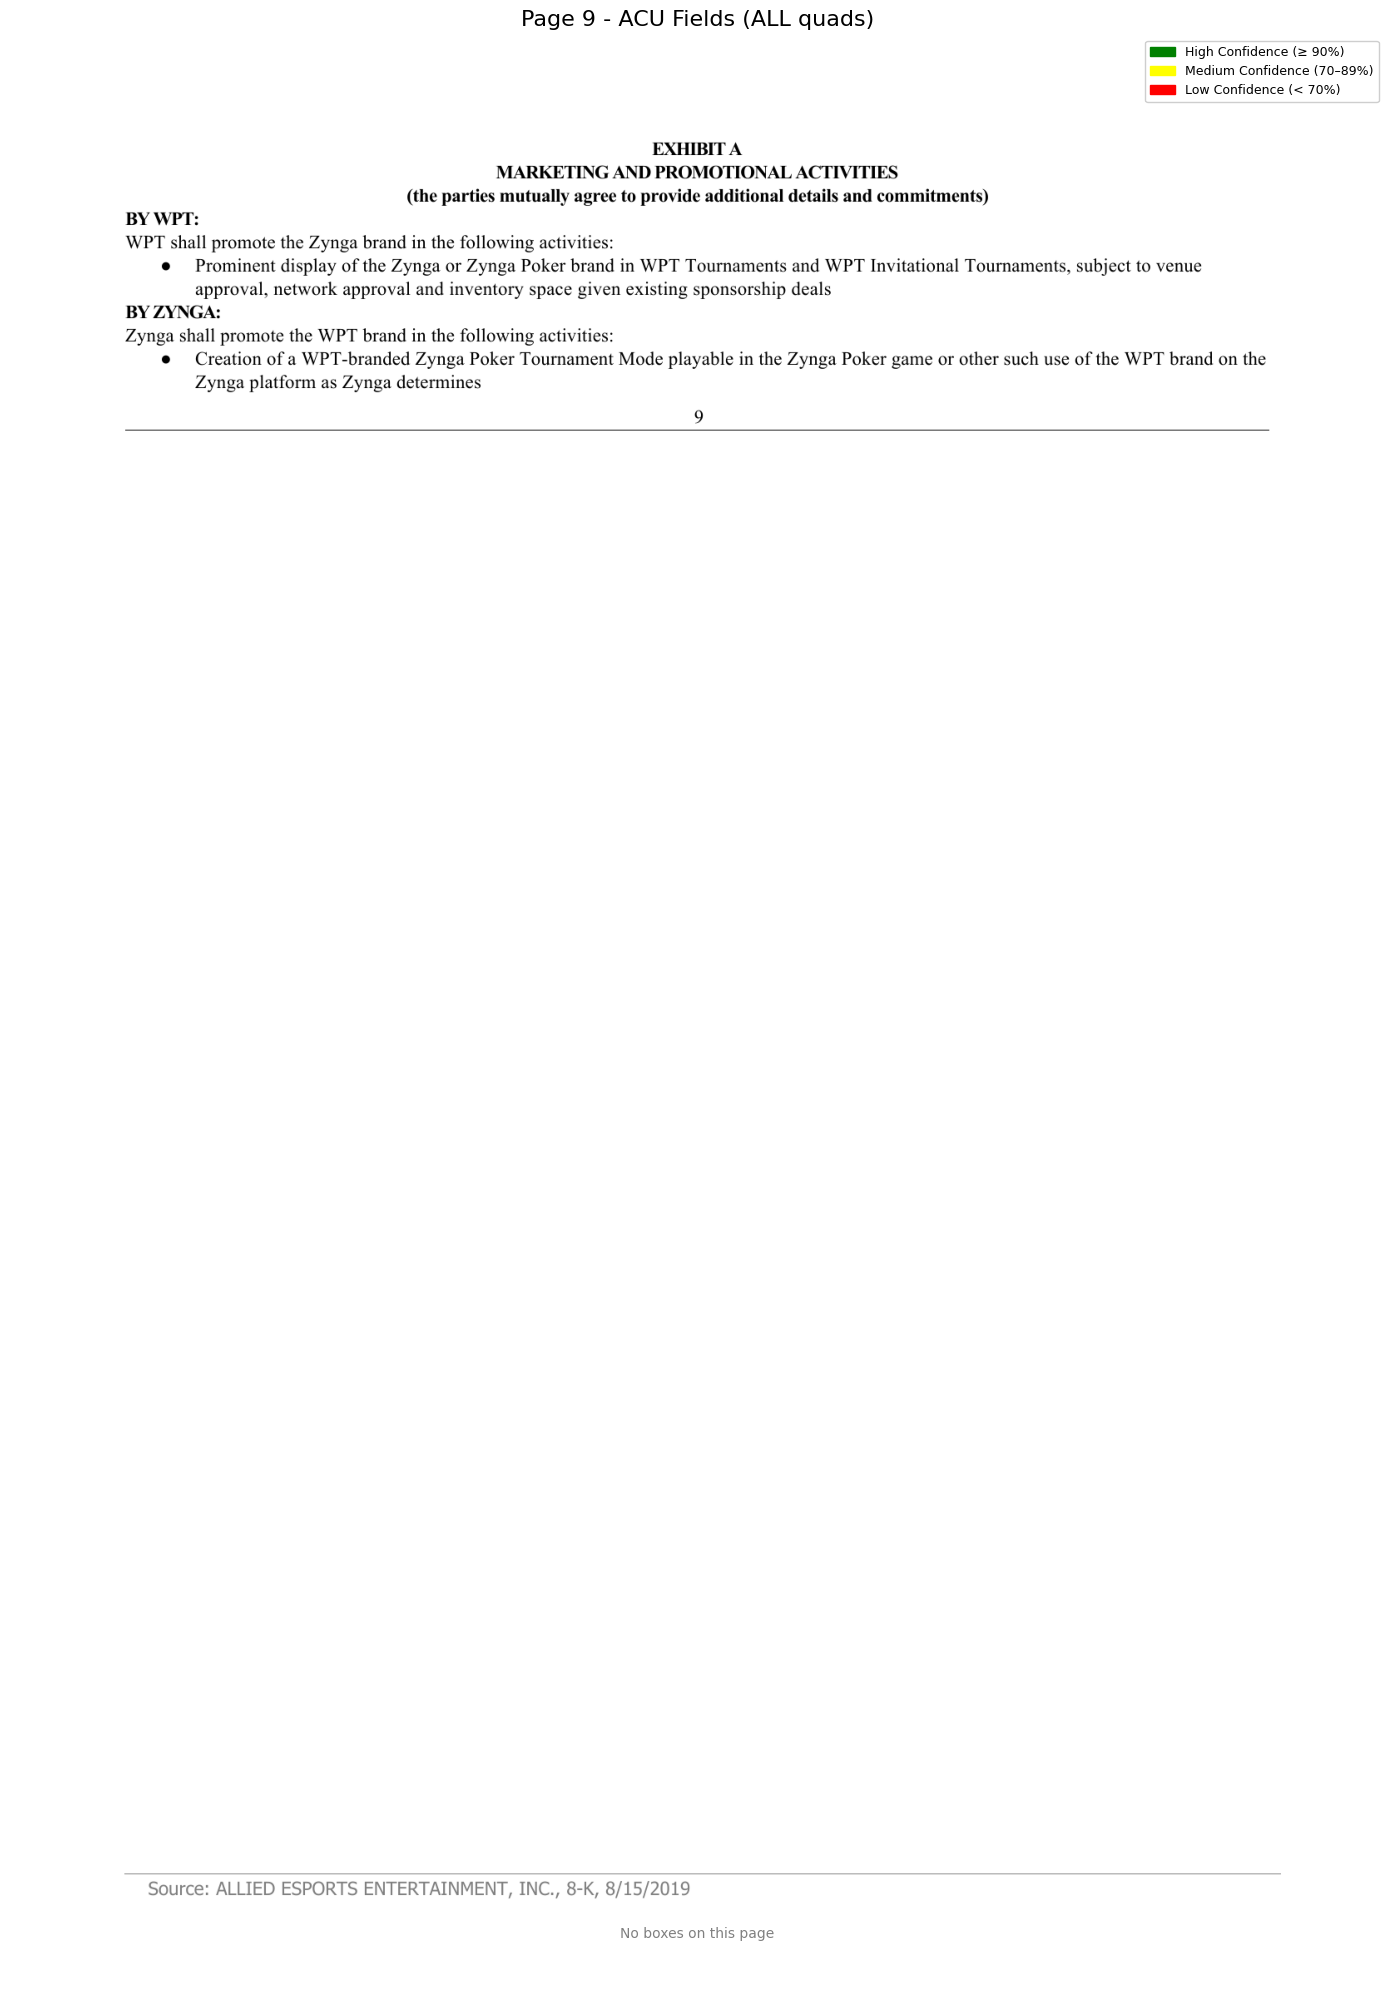

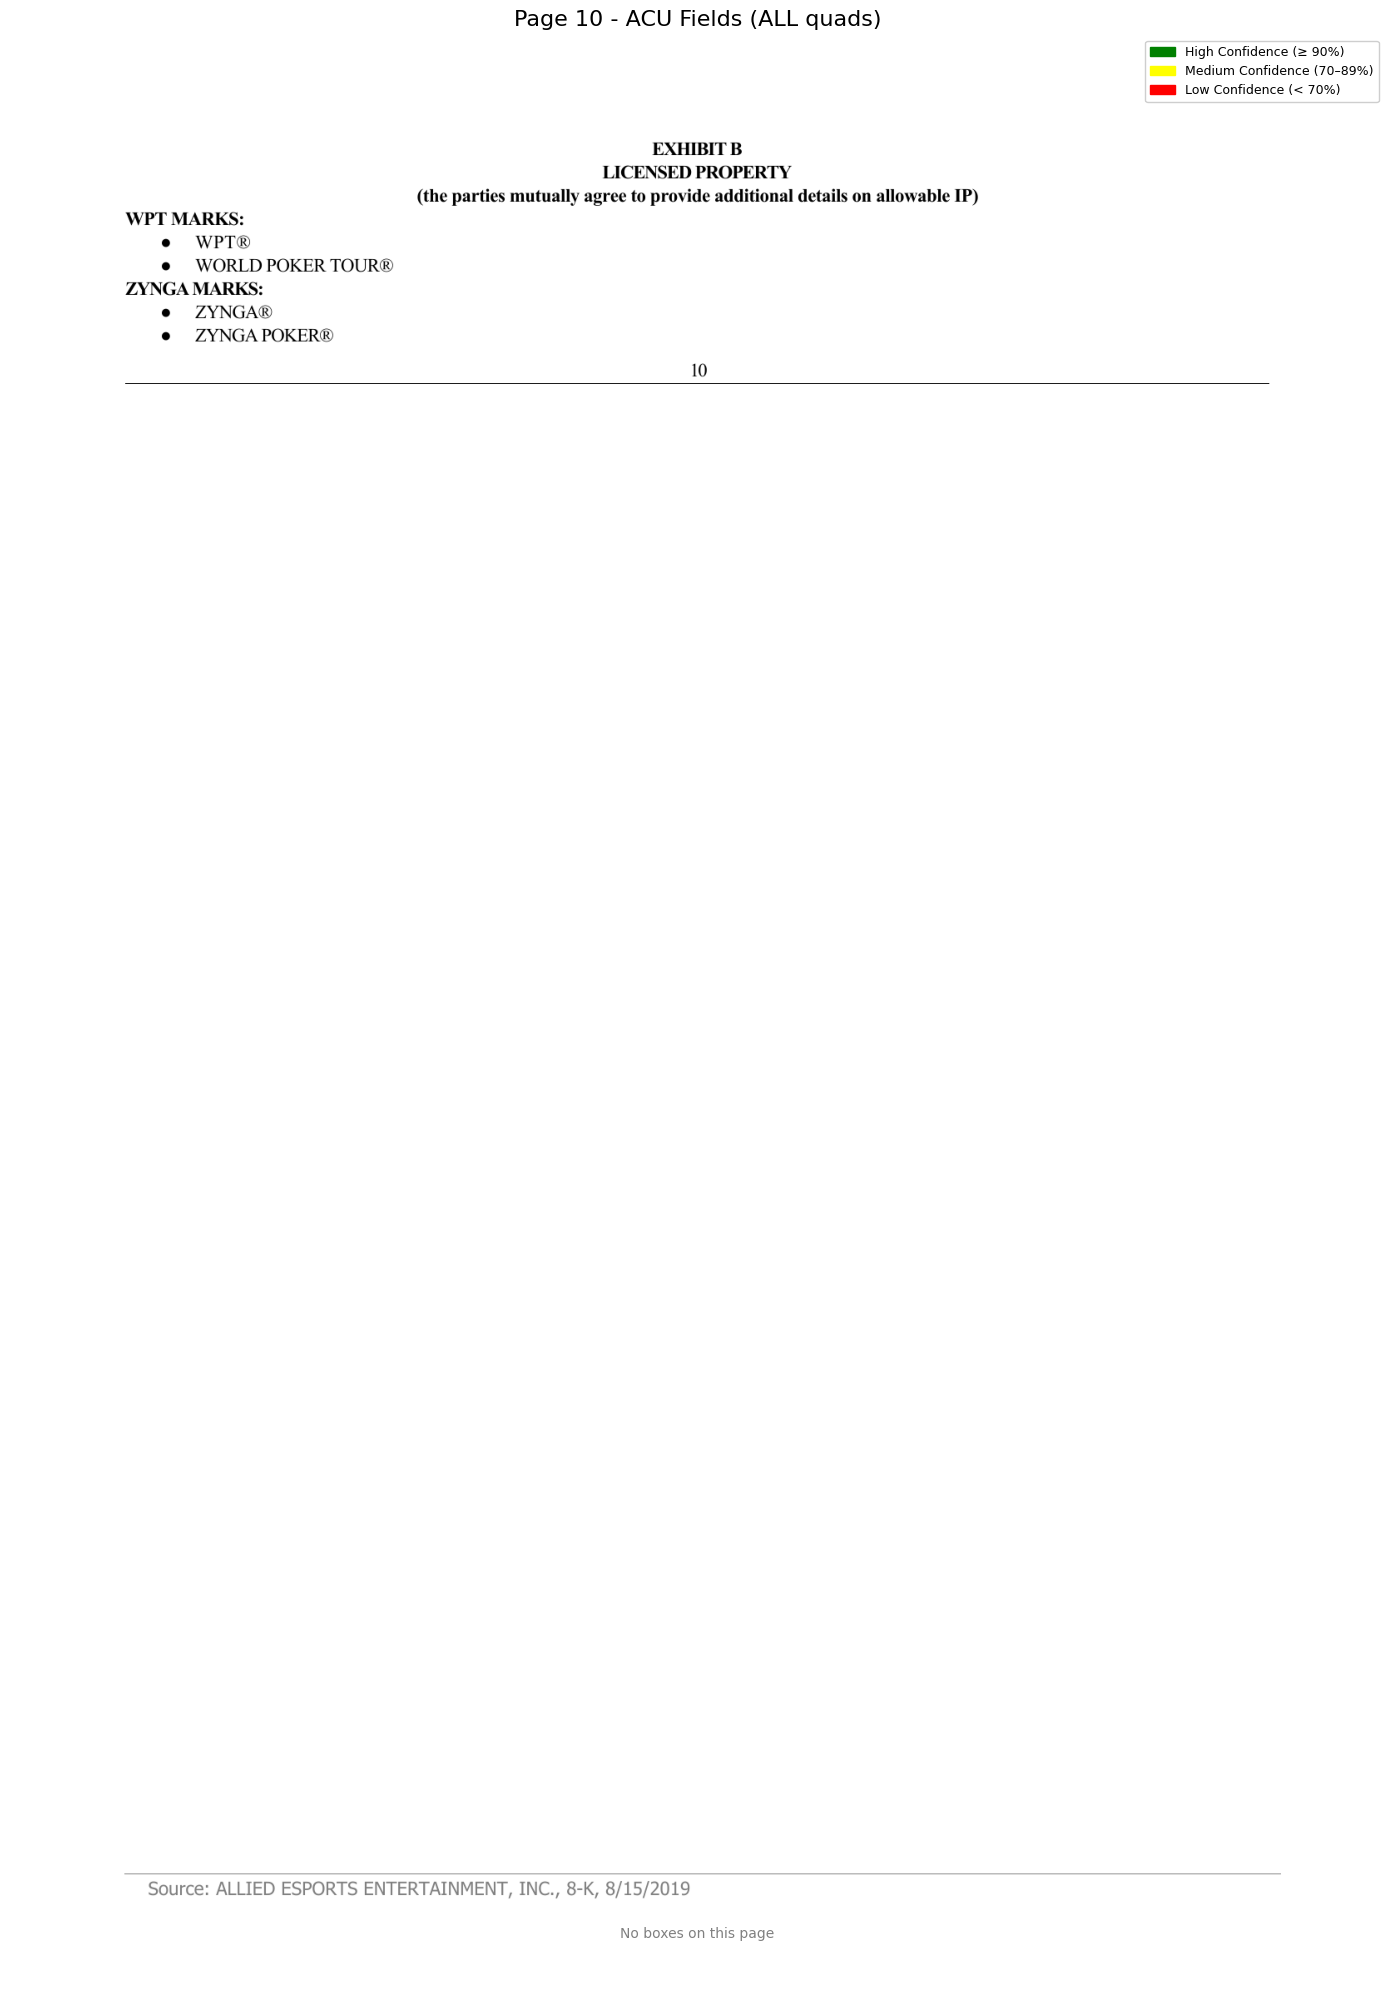

In [21]:
import json
import re
from collections import defaultdict
from typing import Any, Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# confidence mapping
def confidence_color(conf: float | None) -> str:
    if conf is None:
        return "blue"  # fallback (should be rare)
    if conf >= 0.90:
        return "green"
    elif conf >= 0.70:
        return "yellow"
    else:
        return "red"

# --- 1) Parse ALL quads from a source string (supports multiple D(...) blocks) ---

def parse_all_source_quads(source: str) -> List[Tuple[int, List[Tuple[float, float]]]]:
    """
    Returns a list of (page_num, 4-pt quad) tuples.

    Supports:
      - "D(page,x1,y1,...,x4,y4)"
      - multiple D(...) blocks in one string, e.g. "D(...);D(...)" or "D(...) D(...)"
    """
    if not isinstance(source, str):
        return []

    quads = []
    # find all D(...) occurrences
    for inner in re.findall(r"D\(([^)]+)\)", source):
        parts = [p.strip() for p in inner.split(",")]
        if len(parts) != 1 + 8:
            continue
        page_num = int(float(parts[0]))
        coords = list(map(float, parts[1:]))
        pts = list(zip(coords[0::2], coords[1::2]))
        if len(pts) == 4:
            quads.append((page_num, pts))
    return quads


# --- 2) Convert ACU coords to pixels (assuming ACU coords are in same units as page width/height) ---

def quad_to_pixels(pts, page_w, page_h, img_w, img_h):
    return [(x / page_w * img_w, y / page_h * img_h) for x, y in pts]


# --- 3) Extract *multiple* boxes per field/value using source + spans[] ---

def extract_anchored_items(node: Any, path: str) -> List[Dict[str, Any]]:
    """
    Returns list of items with:
      {path, text, confidence, source}
    where source may contain 1 or more D(...) blocks.
    """
    items = []

    if not isinstance(node, dict):
        return items

    # Prefer readable text
    text = node.get("valueString") or node.get("content") or node.get("value") or ""

    # a) top-level source
    if "source" in node and isinstance(node["source"], str):
        items.append({
            "path": path,
            "text": text,
            "confidence": node.get("confidence"),
            "source": node["source"]
        })

    # b) span-level sources (often where additional quads live)
    spans = node.get("spans")
    if isinstance(spans, list):
        for i, sp in enumerate(spans):
            if isinstance(sp, dict) and isinstance(sp.get("source"), str):
                sp_text = sp.get("content") or text  # if span has content, use it
                items.append({
                    "path": f"{path}.spans[{i}]",
                    "text": sp_text,
                    "confidence": sp.get("confidence", node.get("confidence")),
                    "source": sp["source"]
                })

    return items


def extract_sources_from_fields(fields: Dict[str, Any]) -> List[Dict[str, Any]]:
    items = []

    def walk(node, path="fields"):
        if isinstance(node, dict):
            # collect anchored items at this node
            items.extend(extract_anchored_items(node, path))

            # recurse through children
            for k, v in node.items():
                # IMPORTANT: do NOT skip "spans" anymore (we parse it in extract_anchored_items)
                if k in ("source", "span"):  # keep skipping "source" itself to avoid loops
                    continue
                walk(v, f"{path}.{k}")

        elif isinstance(node, list):
            for i, v in enumerate(node):
                walk(v, f"{path}[{i}]")

    walk(fields)
    return items


# --- 4) Visualize: draw ALL quads per item ---

def visualize_acu_fields(json_path: str, pdf_images: List[Any], max_label_len: int = 40):
    data = json.loads(open(json_path, "r", encoding="utf-8").read())
    content = data["result"]["contents"][0]
    page_meta = {p["pageNumber"]: p for p in content["pages"]}

    field_items = extract_sources_from_fields(content["fields"])
    by_page = defaultdict(list)

    for item in field_items:
        for page_num, pts in parse_all_source_quads(item.get("source", "")):
            by_page[page_num].append((item, pts))

    for page_num in range(1, len(pdf_images) + 1):
        img = pdf_images[page_num - 1]
        page = page_meta.get(page_num)
        if not page:
            continue

        fig, ax = plt.subplots(1, 1, figsize=(15, 20))
        ax.imshow(img)
        ax.set_title(f"Page {page_num} - ACU Fields (ALL quads)", fontsize=16)

        items = by_page.get(page_num, [])
        if not items:
            ax.text(0.5, 0.02, "No boxes on this page", transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=10, color="gray")
        else:
            for item, pts in items:
                px_pts = quad_to_pixels(
                    pts,
                    page["width"],
                    page["height"],
                    img.width,
                    img.height
                )

                conf = item.get("confidence")
                color = confidence_color(conf)

                poly = patches.Polygon(
                    px_pts,
                    closed=True,
                    linewidth=1.8,
                    edgecolor=color,
                    facecolor="none",
                    alpha=0.9
                )
                ax.add_patch(poly)

                # Label anchor (top-left of quad)
                x0 = min(p[0] for p in px_pts)
                y0 = min(p[1] for p in px_pts)

                text = (item.get("text") or item.get("path") or "").strip()
                label = text[:max_label_len] + ("..." if len(text) > max_label_len else "")
                if conf is not None:
                    label = f"{label} ({conf*100:.1f}%)"

                ax.annotate(
                    label,
                    (x0, max(0, y0 - 5)),
                    bbox=dict(
                        boxstyle="round,pad=0.3",
                        facecolor="white",
                        edgecolor=color,
                        alpha=0.95
                    ),
                    fontsize=7,
                    color="black",
                    ha="left",
                    va="bottom",
                )

            # for item, pts in items:
            #     px_pts = quad_to_pixels(pts, page["width"], page["height"], img.width, img.height)

            #     poly = patches.Polygon(
            #         px_pts, closed=True, linewidth=1.5, edgecolor="blue",
            #         facecolor="none", alpha=0.8
            #     )
            #     ax.add_patch(poly)

            #     # Better anchor for label: top-left-ish of the quad
            #     x0 = min(p[0] for p in px_pts)
            #     y0 = min(p[1] for p in px_pts)

            #     text = (item.get("text") or item.get("path") or "").strip()
            #     label = text[:max_label_len] + ("..." if len(text) > max_label_len else "")
            #     conf = item.get("confidence")
            #     if conf is not None:
            #         label = f"{label} ({conf*100:.1f}%)"

            #     ax.annotate(
            #         label,
            #         (x0, max(0, y0 - 5)),
            #         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
            #                   edgecolor="blue", alpha=0.9),
            #         fontsize=7,
            #         color="black",
            #         ha="left",
            #         va="bottom",
            #     )

        legend_elements = [
            patches.Patch(color="green", label="High Confidence (≥ 90%)"),
            patches.Patch(color="yellow", label="Medium Confidence (70–89%)"),
            patches.Patch(color="red", label="Low Confidence (< 70%)"),
        ]

        ax.legend(
            handles=legend_elements,
            loc="upper right",
            fontsize=9,
            framealpha=0.95
        )


        ax.set_xlim(0, img.width)
        ax.set_ylim(img.height, 0)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

from pdf2image import convert_from_path
pdf_images = convert_from_path("data/AlliedEsportsEntertainmentInc_20190815_8-K_EX-10.19_11788293_EX-10.19_Content License Agreement.pdf",poppler_path=r"C:\Users\deril\poppler\Library\bin")
visualize_acu_fields(
    r"C:\Users\deril\OneDrive\Desktop\Deril\Development\Azure\Intelligent-Document-Processing-Production-Ready\test_output\license_analysis_result_20260210_131941.json",
    pdf_images
)